# Notebook 2: Coherent States: The Quantum Description of Laser Light

## What are we exploring?

**Coherent states** $|\alpha\rangle$ are the quantum states produced by idealized
single-mode lasers. They are created by applying the **displacement operator** to
the vacuum:
$$|\alpha\rangle = \hat{D}(\alpha)|0\rangle, \quad
\hat{D}(\alpha) = \exp(\alpha\hat{a}^\dagger - \alpha^*\hat{a})$$

Coherent states are eigenstates of the annihilation operator: $\hat{a}|\alpha\rangle = \alpha|\alpha\rangle$.

## Why coherent states are special

Coherent states bridge the quantum-classical divide. They are the **most classical**
quantum states: minimum uncertainty, Poissonian photon statistics, and positive
Wigner functions. At high photon numbers ($|\alpha|^2 \gg 1$), they become
indistinguishable from classical electromagnetic waves.

## Operator and representation note

The displacement operator $\hat{D}(\alpha)$ is a unitary Heisenberg-Weyl group
element acting on bosonic Fock space. It implements phase-space translations and
provides a concrete example of a group action on quantum states.

## Conventions used in this notebook

- Natural units are used for the oscillator algebra: $\hbar=1$.
- `N` is the Hilbert-space dimension, so photon numbers run from `0` to `N-1`.
- Quadratures use $X=(a+a^\dagger)/\sqrt{2}$ and $P=(a-a^\dagger)/(i\sqrt{2})$.
- With QuTiP's standard Wigner scaling, $|\alpha\rangle$ is centered at
  $(\sqrt{2}\,\mathrm{Re}\,\alpha,\sqrt{2}\,\mathrm{Im}\,\alpha)$ on the plotted X,P axes.


## Setup: Imports and Hilbert Space Configuration

In [1]:
from pathlib import Path
import sys
import math
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import qutip

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
from qo_utils import (
    photon_distribution,
    plot_photon_distribution,
    plot_wigner,
    wigner_normalization,
    mean_photon_number,
    photon_variance,
    compute_g2_zero,
    mandel_Q,
    coherent_tail,
    cutoff_from_tail,
)

plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'figure.figsize': (8, 5),
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'text.usetex': False,
    'mathtext.fontset': 'stix',
    'font.family': 'STIXGeneral',
})

# Higher N needed for coherent states -- Poisson distribution extends to larger n
N = 40
a = qutip.destroy(N)
n_op = a.dag() * a

print(f"Hilbert space dimension: N = {N}")
print("Use boundary/tail checks below rather than relying on normalization alone.")

Hilbert space dimension: N = 40
Use boundary/tail checks below rather than relying on normalization alone.


## Creating Coherent States

We create coherent states using `qutip.coherent(N, alpha)`, which implements
$|\alpha\rangle = e^{-|\alpha|^2/2} \sum_n \frac{\alpha^n}{\sqrt{n!}} |n\rangle$.

In [2]:
# Create coherent states for different amplitudes
alphas = [1.0, 2.0, 3.0, 4.0]
coherent_states = {alpha: qutip.coherent(N, alpha) for alpha in alphas}

print("=== Coherent State Properties ===\n")
print(f"{'a':>5} {'<n>':>8} {'|a|^2':>8} {'Dn':>8} {'|a|':>8} "
      f"{'P(N-1)':>10} {'g2(0)':>8} {'Q':>8}")
print("-" * 75)

for alpha in alphas:
    state = coherent_states[alpha]
    mn = mean_photon_number(state, a)
    var = photon_variance(state, a)
    g2 = compute_g2_zero(state, a)
    Q = mandel_Q(state, a)
    P = photon_distribution(state)

    print(f"{alpha:>5.1f} {mn:>8.3f} {alpha**2:>8.1f} {np.sqrt(var):>8.3f} "
          f"{alpha:>8.1f} {P[-1]:>10.2e} {g2:>8.4f} {Q:>8.4f}")

=== Coherent State Properties ===

    a      <n>    |a|^2       Dn      |a|     P(N-1)    g2(0)        Q
---------------------------------------------------------------------------
  1.0    1.000      1.0    1.000      1.0   0.00e+00   1.0000   0.0000
  2.0    4.000      4.0    2.000      2.0   0.00e+00   1.0000   0.0000
  3.0    9.000      9.0    3.000      3.0   1.48e-13   1.0000  -0.0000
  4.0   16.000     16.0    4.000      4.0   9.83e-07   1.0000  -0.0000


All coherent states show $\langle n \rangle \approx |\alpha|^2$,
$\Delta n \approx |\alpha|$, $g^{(2)}(0) \approx 1.0$, and $Q \approx 0$.
The boundary probability $P(N-1)$ is tiny, confirming adequate truncation.

## Eigenvalue Verification: $\hat{a}|\alpha\rangle = \alpha|\alpha\rangle$

Coherent states are the **eigenstates of the annihilation operator**. Let's
verify this numerically by computing the residual $\| \hat{a}|\alpha\rangle - \alpha|\alpha\rangle \|$.

In [3]:
print("=== Eigenvalue check: a|alpha> = alpha|alpha> ===\n")
print(f"{'alpha':>8}  {'residual':>12}  {'tail(N,|a|)':>12}  {'comment'}")
print("-" * 60)
for alpha in alphas:
    state = coherent_states[alpha]
    residual = (a * state - alpha * state).norm()
    tail = coherent_tail(N, alpha)
    comment = "exact" if residual < 1e-10 else f"truncation ({tail:.1e} tail)"
    print(f"{alpha:>8.1f}  {residual:>12.2e}  {tail:>12.2e}  {comment}")
# Small alpha: eigenvalue relation is exact to machine precision
# Large alpha: residual grows because the state spills past the truncation boundary
assert (a * coherent_states[1.0] - 1.0 * coherent_states[1.0]).norm() < 1e-10
print("\n[PASS] Eigenvalue check: exact for alpha=1, degrades for alpha->N boundary (truncation)")

=== Eigenvalue check: a|alpha> = alpha|alpha> ===

   alpha      residual   tail(N,|a|)  comment
------------------------------------------------------------
     1.0      4.46e-16      4.62e-49  exact
     2.0      1.20e-12      3.01e-26  exact
     3.0      1.30e-06      2.86e-14  truncation (2.9e-14 tail)
     4.0      5.00e-03      3.28e-07  truncation (3.3e-07 tail)

[PASS] Eigenvalue check: exact for alpha=1, degrades for alpha->N boundary (truncation)


The residual for $\alpha = 1$ is at machine precision ($\sim 10^{-16}$), confirming
exact eigenvalue behavior. For $\alpha = 4$, the residual is $\sim 10^{-3}$ because
the coherent state extends beyond our $N=40$ truncation — the same truncation effect
we've been tracking with boundary probabilities and tail masses.

## Photon Number Distributions — Poissonian Statistics

For a coherent state $|\alpha\rangle$, the photon number distribution is Poissonian:
$$P(n) = e^{-|\alpha|^2} \frac{|\alpha|^{2n}}{n!}$$

The mean and variance are both equal to $|\alpha|^2$.

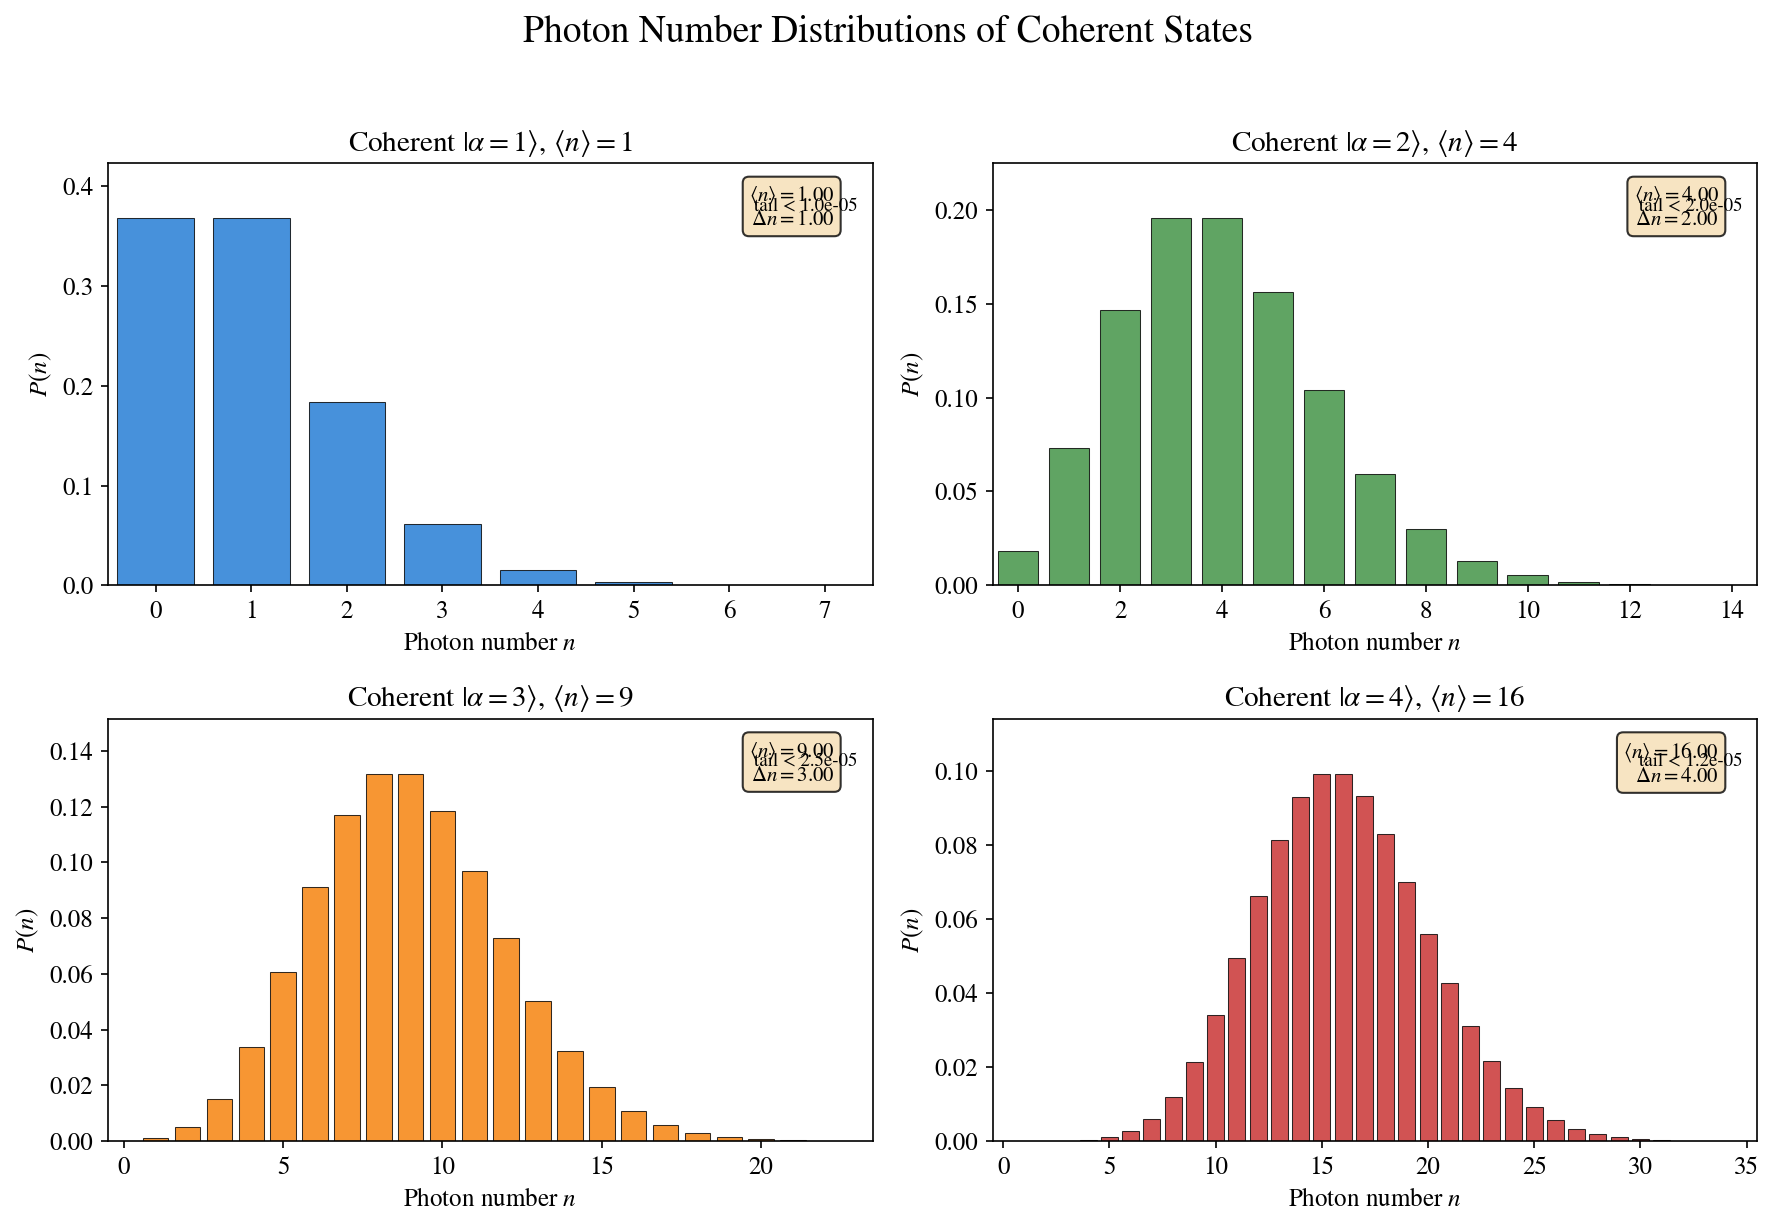

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
colors = ['#1976D2', '#388E3C', '#F57C00', '#C62828']

for idx, (alpha, color) in enumerate(zip(alphas, colors)):
    ax = axes[idx // 2, idx % 2]
    state = coherent_states[alpha]
    n_plot = cutoff_from_tail(
        lambda cutoff, alpha=alpha: coherent_tail(cutoff, alpha),
        tolerance=1e-3,
        start=int(alpha**2 + 5*np.sqrt(alpha**2 + 1)),
    )
    tail_omitted = coherent_tail(n_plot, alpha)
    plot_photon_distribution(state, n_max=n_plot,
                             title=rf'Coherent $|\alpha={alpha:.0f}\rangle$, '
                                   rf'$\langle n \rangle = {alpha**2:.0f}$',
                             ax=ax, color=color, show_stats=True)
    ax.text(0.98, 0.92, f"tail < {tail_omitted:.1e}",
            transform=ax.transAxes, ha='right', va='top', fontsize=9)

plt.suptitle('Photon Number Distributions of Coherent States', fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'coherent_photon_distributions.png', bbox_inches='tight', dpi=300)
plt.savefig(FIG_DIR / 'coherent_photon_distributions.svg', bbox_inches='tight')
plt.show()